##Names: Mamello Malape
Student Number : 2023232750

In [ ]:
!pip  install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression

In [ ]:
df= pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'

2.

In [ ]:
#summary of data
df.dtypes

In [ ]:
#Convert Total charges to numeric as it is an object
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dtypes

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Summary of the Dataset

In [ ]:
#1Number of Customers
print("Number of Customers:", len(df))
#Number of Churned vs Retained customers
print("Number of Churned Customers:", len(df[df["Churn"] == "Yes"]))
print("Number of Retained Customers:", len(df[df ["Churn"] == "No"]))
#Number of missing values
print("Number of missing values:", df.isnull().sum().sum())

Number of Customers: 7043
Number of Churned Customers: 1869
Number of Retained Customers: 5174
Number of missing values: 11


Visualisation of The Results

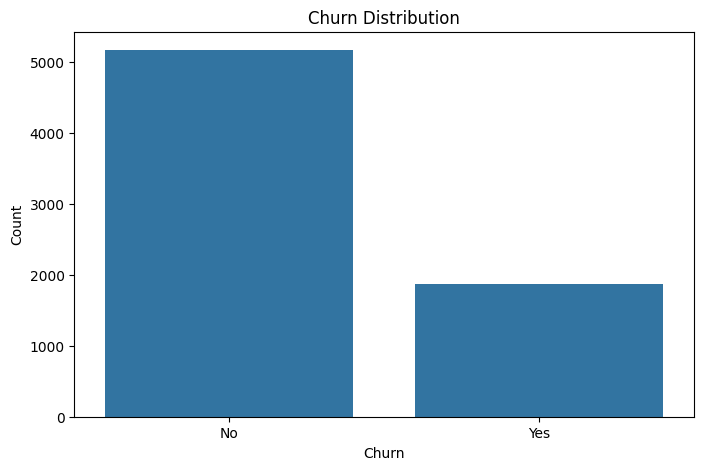

In [ ]:
#Visualisation of results for Churned(Yes) and Retained Customers(No)
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=df )
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

#Part B

Due to Total charges having missing values we decided to churn by Total charges. To see its distribution


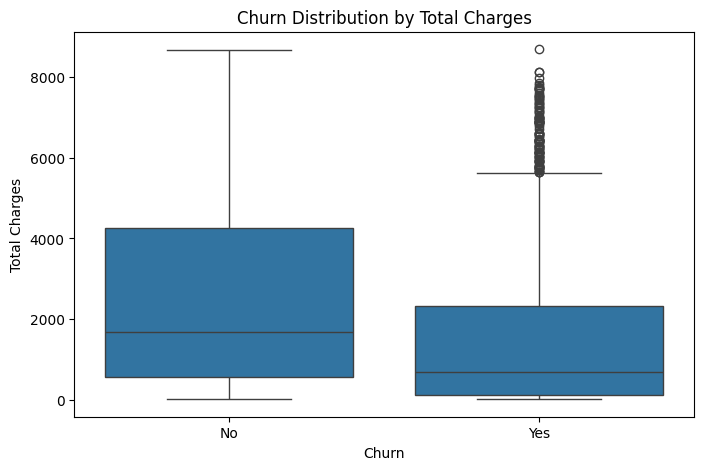

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title("Churn Distribution by Total Charges")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

Viualise the churn Distribution By Contract type

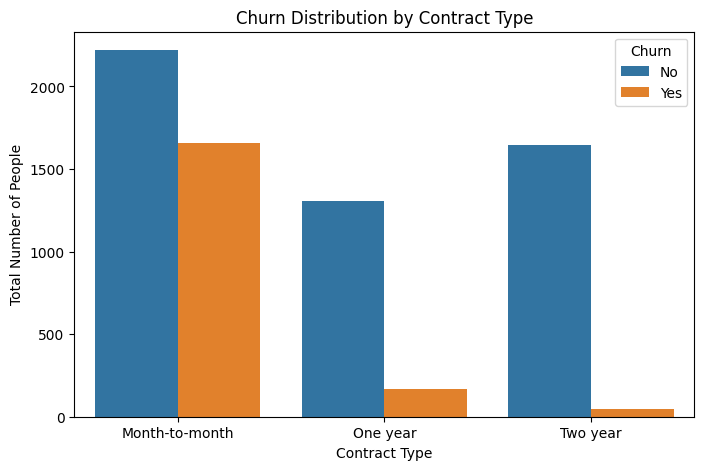

In [ ]:
#Churn By contact type

plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Total Number of People')
plt.show()



In [ ]:
#Summary
df.groupby("Contract").agg({"Churn": "value_counts"})

Churn
Contract       Churn       
Month-to-month No      2220
               Yes     1655
One year       No      1307
               Yes      166
Two year       No      1647
               Yes       48

Viualise the churn Distribution By Internet Service type

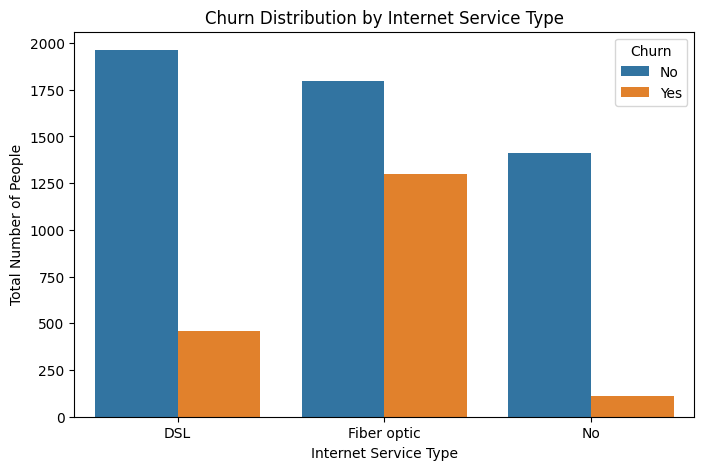

In [ ]:
#Churn by Internet service
plt.figure(figsize=(8, 5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn Distribution by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Total Number of People')
plt.show()



In [ ]:
#Summary
df.groupby("InternetService").agg({"Churn": "value_counts"})

Churn
InternetService Churn       
DSL             No      1962
                Yes      459
Fiber optic     No      1799
                Yes     1297
No              No      1413
                Yes      113

Viualise the churn Distribution By Payment method

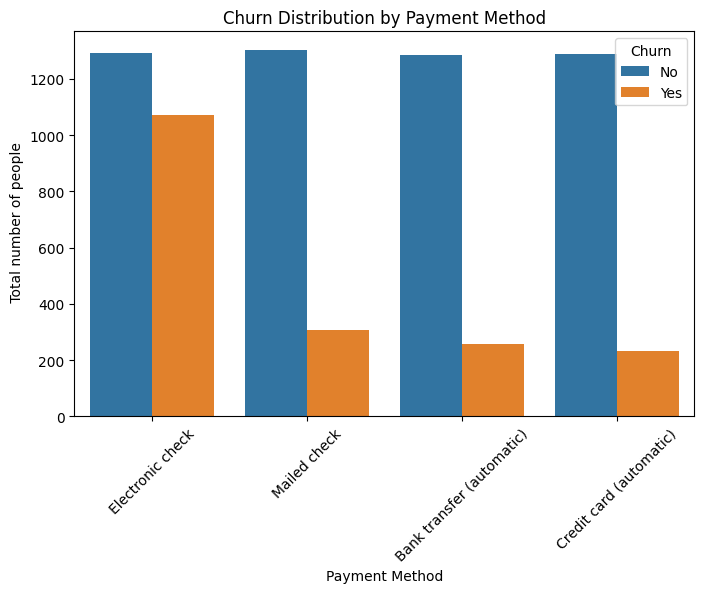

In [ ]:
#Churn by Payment method
plt.figure(figsize=(8, 5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, )
plt.title('Churn Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel(' Total number of people')
plt.xticks(rotation=45)
plt.show()


In [ ]:
#summary
df.groupby("PaymentMethod").agg({"Churn": "value_counts"})

Churn
PaymentMethod             Churn       
Bank transfer (automatic) No      1286
                          Yes      258
Credit card (automatic)   No      1290
                          Yes      232
Electronic check          No      1294
                          Yes     1071
Mailed check              No      1304
                          Yes      308

Visualize Churn distribution by Tenure

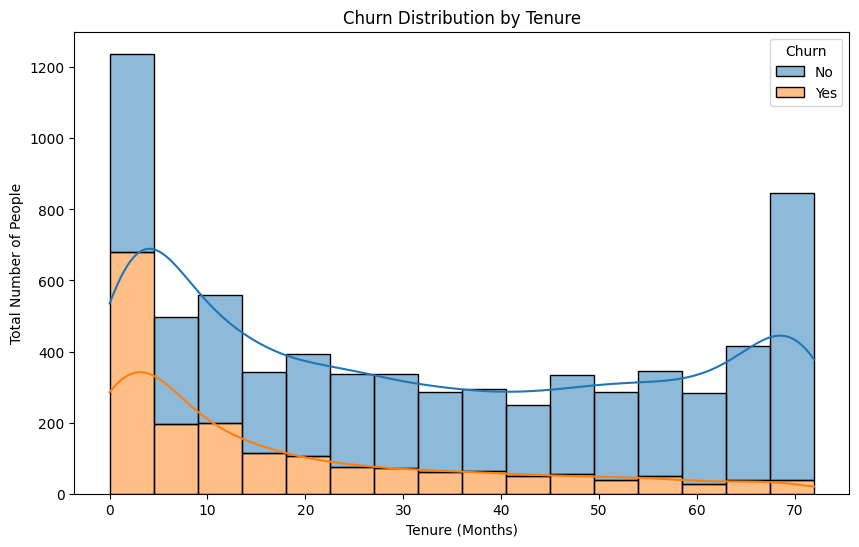

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the histogram with a KDE line
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', kde=True)

# Customize the plot with a title and labels
plt.title('Churn Distribution by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Total Number of People')

# Show the plot
plt.show()


/tmp/ipython-input-4075327100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


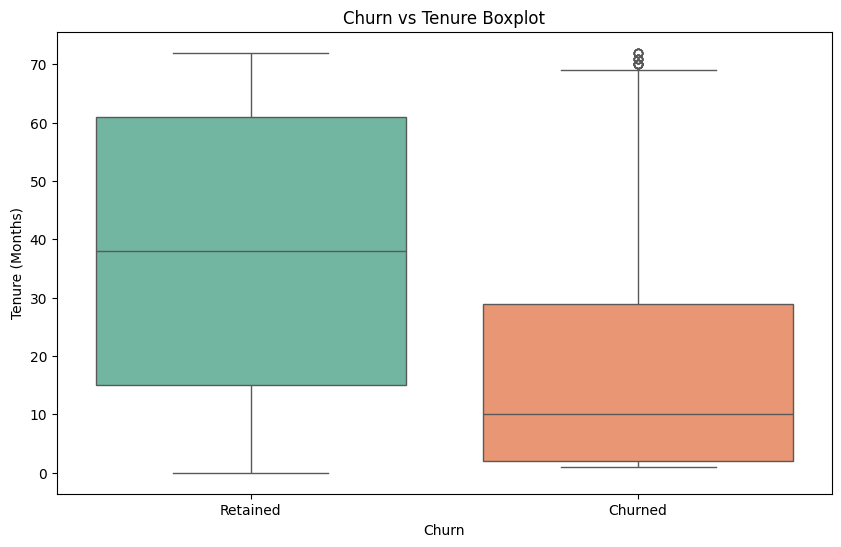

In [ ]:
# Boxplot for Tenure distribution by churn
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Churn vs Tenure Boxplot')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.show()

In [ ]:
#Summary
df.groupby("tenure").agg({"Churn": "value_counts"})

Churn
tenure Churn       
0      No        11
1      Yes      380
       No       233
2      Yes      123
       No       115
...             ...
70     Yes       11
71     No       164
       Yes        6
72     No       356
       Yes        6

[145 rows x 1 columns]

2.
Churn Rates by Gender

In [ ]:
#Churn rate for gender and divide each by the total number of customers

Gender_rates =df.groupby("gender").agg({"Churn": "value_counts"})

round(Gender_rates/len(df)*100,1)




Churn
gender Churn       
Female No      36.2
       Yes     13.3
Male   No      37.3
       Yes     13.2

Churn Rates by Senior citizen

In [ ]:
#Assigning Senior Citzen Values
df['SeniorCitizen'] = df['SeniorCitizen'].apply(lambda x: 'Yes' if x == 1 else 'No')


In [ ]:
#churn by Snior citizen
SeniorCitizen_Rates=df.groupby("SeniorCitizen").agg({"Churn": "value_counts"})
round(SeniorCitizen_Rates/len(df)*100,1)


Churn
SeniorCitizen Churn       
No            No      64.0
              Yes     19.8
Yes           No       9.5
              Yes      6.8

Churn Rates by Partner

In [ ]:
#churn by partner
PartnerCitizen_rates = df.groupby("Partner").agg({"Churn": "value_counts"})
round(PartnerCitizen_rates/len(df)*100,1)

Churn
Partner Churn       
No      No      34.7
        Yes     17.0
Yes     No      38.8
        Yes      9.5

#Part C

In [ ]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
list(cat_cols)

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [ ]:
# Drop CustomerId as it is not useful for our prediction
df.drop("customerID", axis=1, inplace=True)

In [ ]:
#Checking column CustomerID column has been droped
df.columns


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Encoding Categorical values using, One Hot Column Encoder as to convert categorical data into a numerical format so that machine learning algorithms can process it effectively.

And then  split the dataset into 70/30, as 70% of the data is used to train the model.
30% of the data is used to test the model after training.

In [ ]:

# Identify categorical columns again after dropping customerID
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

print("Data after Label Encoding:")
display(df.head())

  #Feature(X) and Target(y)
X = df.drop('Churn', axis=1)
y = df['Churn']
 #Train-Test split(70/30)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Train Sample :", X_train.shape[0])
print("Test sample:", X_test.shape[0])

Data after Label Encoding:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


Train Sample : 4930
Test sample: 2113


##2.Training a Model Using KNN And Logistc Regession

Account for missing values found on Total_Charges, the presence of missing data in a dataset can cause problems for machine learning algorithms and statistical analyses(Logistic regression)

In [ ]:
# Create imputer (use mean for numeric data)
imputer = SimpleImputer(strategy="mean")

# Apply imputer to X
X_imputed = imputer.fit_transform(X)

For KNN model

In [ ]:
# Scale features (important for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)



# Train-test split again
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"After imputation, training samples: {X_train.shape[0]}")

After imputation, training samples: 5634


In [ ]:
knn = KNeighborsClassifier()


param_grid = {
    'n_neighbors': [15,17,21,25],
    'weights': [ 'uniform','distance'],
    'metric': ['euclidean', 'manhattan']
}

# Grid Search with 5-fold CV
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
     error_score='raise'
)

grid_search.fit(X_train, y_train)

print("\nBest Hyperparameters found:")
print(grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

best_knn = grid_search.best_estimator_


Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Hyperparameters found:
{'metric': 'manhattan', 'n_neighbors': 25, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.7939


In [ ]:
#predictions
y_pred_knn = best_knn.predict(X_test)

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred_knn)
print(f"Test Accuracy: {acc:.4f}")

#precision
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred_knn)
print(f"Precision: {precision:.4f}")

#Recall
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

recall=recall_score(y_test, y_pred_knn)
print(f"Recall: {recall:.4f}")


#F1_Score
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred_knn)
print(f"F1 Score: {f1:.4f}")




Test Accuracy: 0.7857
Precision: 0.5989
Recall: 0.5829
F1 Score: 0.5908


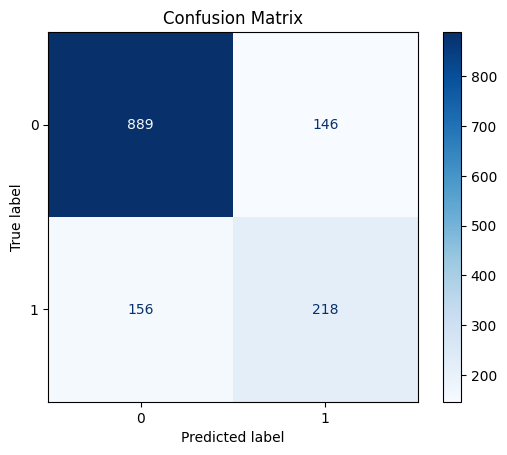

In [ ]:

#Confusion matrix

cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



Learning curve,ROC curve,Precision-Recall Curve for KNN.

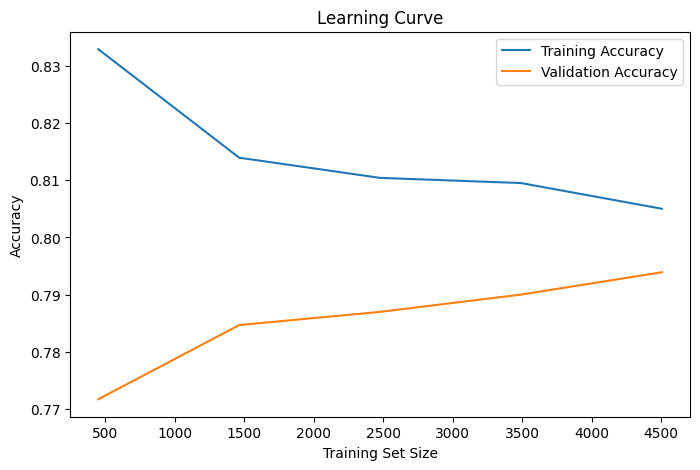

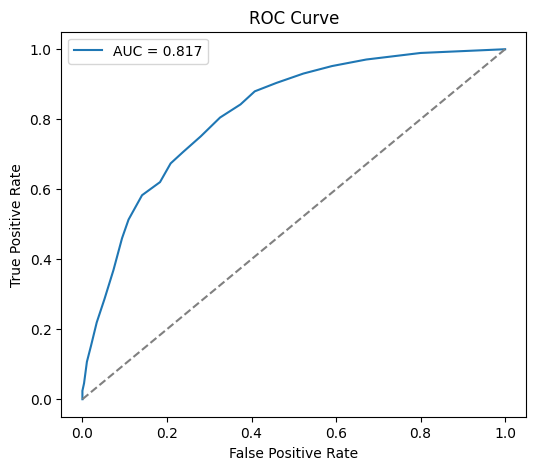

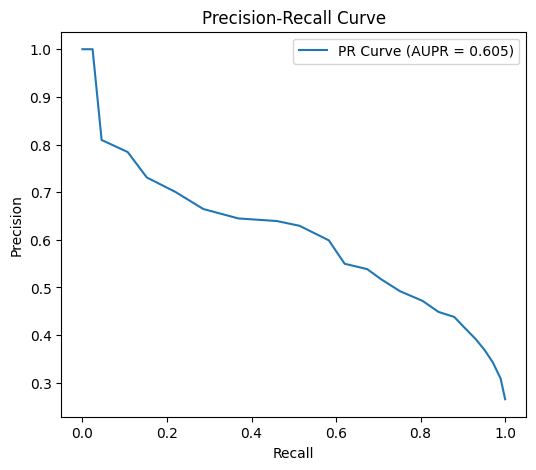

In [ ]:
 #Learning curve for Knn
from sklearn.model_selection import learning_curve
 #Learning Curve (accuracy vs training size)
train_sizes, train_scores, test_scores = learning_curve(
    best_knn, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

# ROC Curve
y_prob = best_knn.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

aupr = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR Curve (AUPR = {aupr:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

Logistic regression model

In [ ]:

# Create imputer (use mean for numeric data)
imputer_log = SimpleImputer(strategy="mean")

# Apply imputer to training data
X_train_imputed_log = imputer_log.fit_transform(X_train)

# Scale features (important for Logistic Regression with L1 penalty)
scaler_log = StandardScaler()
X_train_scaled_log= scaler_log.fit_transform(X_train_imputed_log)

# Apply the same imputer and scaler to the test data
X_test_imputed_log = imputer_log.transform(X_test)
X_test_scaled_log = scaler_log.transform(X_test_imputed_log)


#Model ------
df_Model= LogisticRegression(
penalty = "l1",
C=1.0,
random_state=2025,
max_iter=1000,
solver="saga")
df_Model.fit(X_train_scaled_log,y_train)

LogisticRegression(max_iter=1000, penalty='l1', random_state=2025,
                   solver='saga')

Test Accuracy: 0.8088
Precision: 0.6778
Recall: 0.5645
F1 Score: 0.6160


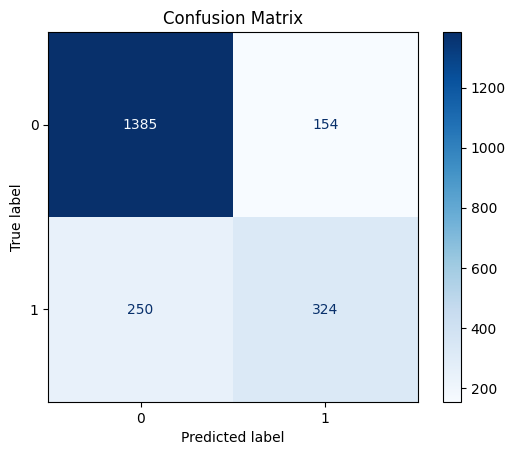

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# predictions for logistic regression
y_pred_log = df_Model.predict(X_test_scaled_log)

# accuracy score
acc = accuracy_score(y_test, y_pred_log)
print(f"Test Accuracy: {acc:.4f}")

#precision
precision = precision_score(y_test, y_pred_log)
print(f"Precision: {precision:.4f}")

#Recall
recall=recall_score(y_test, y_pred_log)
print(f"Recall: {recall:.4f}")

#F1_SCORE
f1 = f1_score(y_test, y_pred_log)
print(f"F1 Score: {f1:.4f}")



#Confusion matrix plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=df_Model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()



In [ ]:
# Classification Report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1539
           1       0.68      0.56      0.62       574

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113



Learning curve,ROC curve,Precision-Recall Curve for logistic regression.

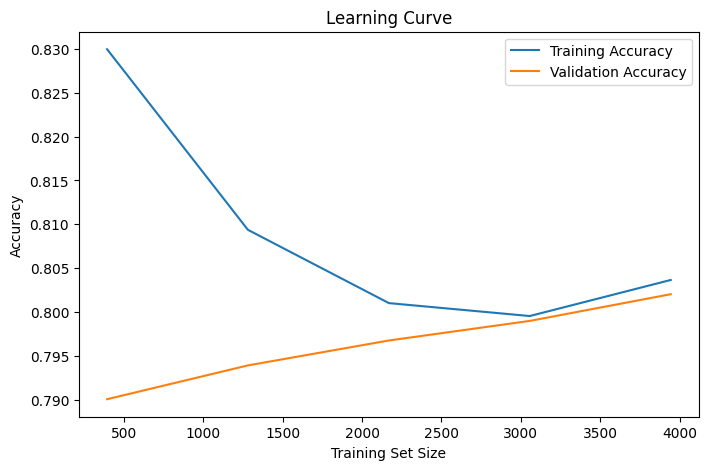

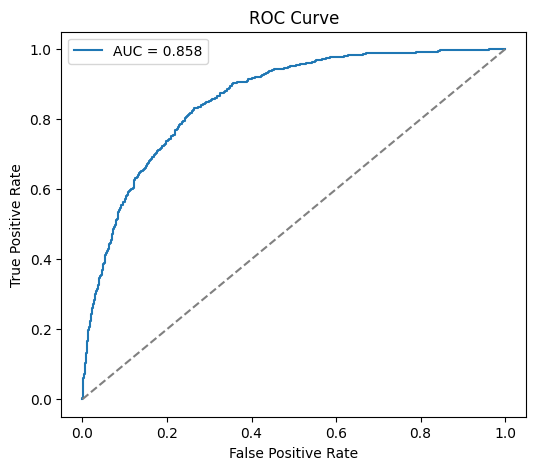

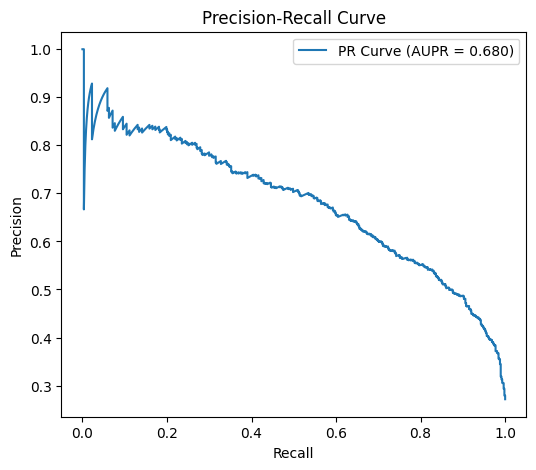

In [ ]:
#Learning curve for logistic regression
from sklearn.model_selection import learning_curve

from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Learning Curve (accuracy vs training size)
train_sizes, train_scores, test_scores = learning_curve(
    df_Model, X_train_scaled_log, y_train, cv=5, scoring='accuracy', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

# ROC Curve
y_prob = df_Model.predict_proba(X_test_scaled_log)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

aupr = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR Curve (AUPR = {aupr:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

#Part D

Made use of heatmap to determine Features which are mostly important for predicting churn

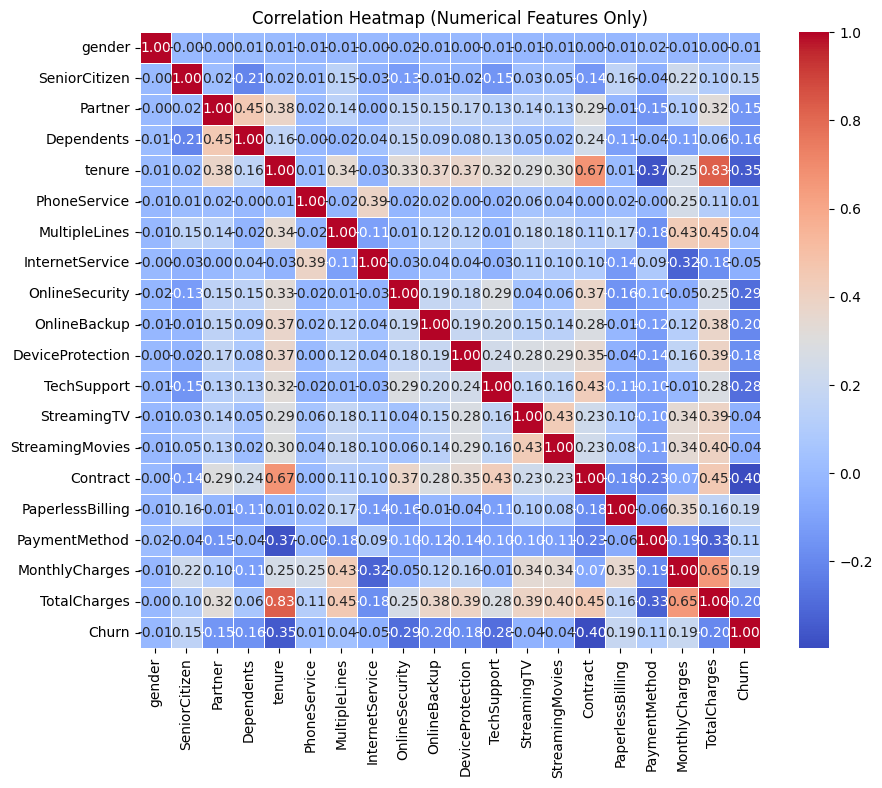

In [ ]:

# Compute correlation matrix
numerical_cols = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numerical_cols.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numerical Features Only)")
plt.show()

Below heatmap shows the important Features for predicting churn.

Being:1.Contract
      2.Tenure
      3.Sercurity
      4.Total Churges
      5.Tech Surpport
      

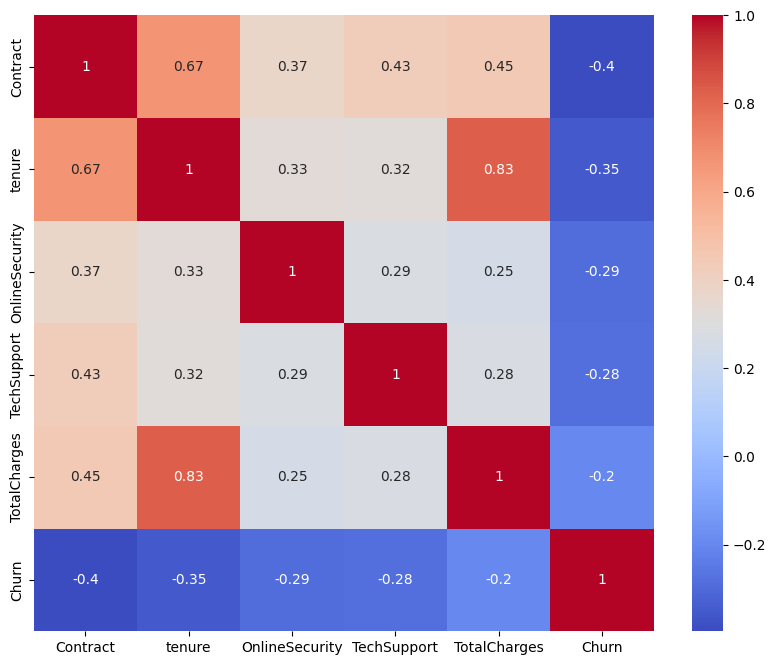

In [ ]:
df_encoded = pd.get_dummies(df)


#heatmap Displaying most important features for predicting churn
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded[['Contract', 'tenure', 'OnlineSecurity', 'TechSupport', 'TotalCharges','Churn']].corr(), annot=True, cmap='coolwarm')
plt.show()